# Author topic contribution

In [8]:
import pandas as pd

topic_doc_file = '../../../Papers/2025/cultural-evolution-topics/data/titles_with_topics.csv'
metadata_file = '../metadata/DBNL-publication_author_metadata.tsv'


In [10]:
meta_df = pd.read_csv(metadata_file, sep='\t')
meta_df

,ti_id,titel,jaar,druk,categorie,voornaam,voorvoegsel,achternaam,uitgever,plaats_van_uitgave,...,dob_day,dob_month,dob_year,dob_century,dod_string,dod_location,dod_day,dod_month,dod_year,dod_century
0,kist001leve01,"Het leven, gevoelens en zonderlinge reize van ...",1800,1ste druk,werk,Willem,NaN,Kist,NaN,Haarlem,...,1.0,9.0,1758.0,18.0,Arnhem 5 januari 1841,Arnhem,5.0,1.0,1841.0,19.0
1,stre001char01,"Charakters en lotgevallen van Adelson, Héloïse...",1804,1ste druk,werk,Naatje,van,Streek-Brinkman,Gerbrand Roos,Amsterdam,...,NaN,NaN,1760.0,18.0,Den Haag 4 juli 1828,Den Haag,4.0,7.0,1828.0,19.0
2,daal002will01,Willem Hups. Eene anecdote uit de XVII eeuw; o...,1805,1ste druk,werk,Bruno,NaN,Daalberg,J. Immerzeel Jr.,Den Hage,...,9.0,8.0,1758.0,18.0,Den Haag 8 december 1818,Den Haag,8.0,12.0,1818.0,19.0
3,bodd002leve01,Levensgeschiedenis van den vermaarden dichter,1805,1ste druk,uitgave,Pieter,NaN,Boddaert jr.,NaN,NaN,...,NaN,10.0,1766.0,18.0,Amsterdam 8 maart 1805,Amsterdam,8.0,3.0,1805.0,19.0
4,loos005hist01,Historie van Mejuffrouw Susanna Bronkhorst. De...,1806,1ste druk,werk,Adriaan,NaN,Loosjes,NaN,NaN,...,13.0,5.0,1761.0,18.0,Haarlem 28 februari 1818,Haarlem,28.0,2.0,1818.0,19.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2061,merw017coff02,Coffy de negerslaaf,ca. 1970,2de druk,uitgave,H.,te,Merwe,W.D. Meinema,Delft,...,22.0,1.0,1896.0,19.0,Hoek van Holland 19 september 1977,Hoek van Holland,19.0,9.0,1977.0,20.0
2062,aard002stij01,Stijfkopje omnibus (onder pseudoniem Ankie Aal...,ca. 1970,herdruk,herdruk,H.P.,van den,Aardweg,Geka,Alphen aan de Rijn,...,19.0,7.0,1899.0,19.0,Amsterdam 4 juli 1971,Amsterdam,4.0,7.0,1971.0,20.0
2063,gras003daar01,"Daar ga je, Claudia!",ca. 1970-1980,?,werk,Cok,NaN,Grashoff,Het Goede Boek / Standaard,Huizen / Antwerpen,...,5.0,1.0,1928.0,20.0,11 juni 2020,11,NaN,6.0,2020.0,21.0
2064,nijn001tolh02,"Tolhuis ""Het zwarte paard""",na 1941,herdruk,herdruk,H.J.,van,Nijnatten-Doffegnies,Westfriesland,Hoorn,...,NaN,2.0,1898.0,19.0,30 april 1990,30,NaN,4.0,1990.0,20.0


In [119]:
def make_full_name(row):
    name_fields = ['voornaam', 'voorvoegsel', 'achternaam']
    parts = [row[name_field] for name_field in name_fields if pd.isna(row[name_field]) is False]
    return ' '.join(parts)
    
meta_df['full_name'] = meta_df.apply(make_full_name, axis=1)

In [120]:
topic_doc = pd.read_csv(topic_doc_file)
topic_doc = pd.merge(meta_df, topic_doc, left_on=['ti_id', 'author_id'], right_on=['docid', 'author_id'])
topic_doc.head(2)

,ti_id,titel,jaar,druk,categorie,voornaam,voorvoegsel,achternaam,uitgever,plaats_van_uitgave,...,topic_091,topic_092,topic_093,topic_094,topic_095,topic_096,topic_097,topic_098,topic_099,topic_100
0,kerc007voll07,Volledige werken. Deel 6,1870,1ste druk,uitgave,Pieter Frans,van,Kerckhoven,L. de Cort,NaN,...,0.000023,0.008481,0.001937,0.000760,0.000702,0.001462,0.005243,0.002374,0.000477,0.000201
1,twai001lotg11,"De lotgevallen van Huckleberry Finn, Tom Sawye...",1885,2de druk,herdruk,Mark,NaN,Twain,Van Holkema & Warendorf,Amsterdam,...,0.000078,0.006208,0.005536,0.010296,0.007696,0.019110,0.000182,0.001575,0.043594,0.001235


In [121]:
# Select the columns to display to be able to identify titles and authors
show_cols = ['docid', 'author_id', 'full_name', 'titel', 'corrected_comp_year', 'period']

In [122]:
topic_doc['period'] = topic_doc.corrected_comp_year.apply(lambda x: int(x/5) * 5)
topic_doc.period.value_counts()

period
1930    119
1920    112
1935     95
1945     93
1900     90
1925     89
1905     86
1965     75
1915     69
1950     69
1895     68
1940     62
1890     57
1910     57
1960     46
1955     44
1885     43
1970     42
Name: count, dtype: int64

Each period has at least 42 titles, but most will have a low probability for most topics. Therefore, it makes sense to zoom in on only titles with a probability above a certain threshold. Let's first look at the probability distribution to determine a sensible threshold.

## Probability distribution

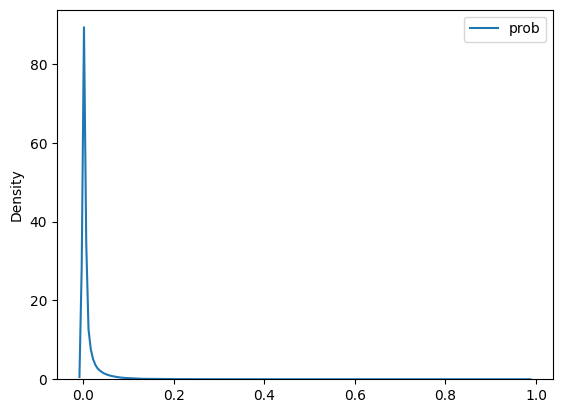

In [123]:
import seaborn as sns

topic_cols = [col for col in topic_doc.columns if col.startswith('topic_')]
ax = sns.kdeplot(topic_doc[topic_cols].melt(value_name='prob'))


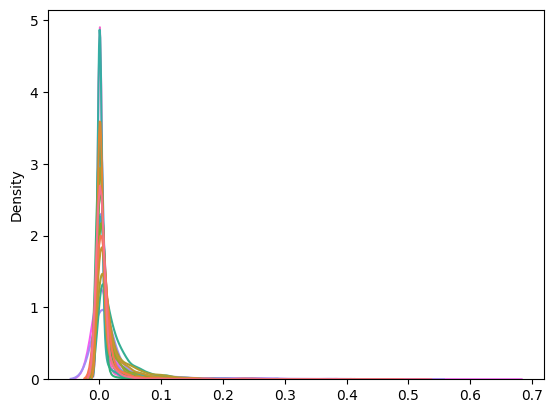

In [124]:
topic_nums = [f'topic_{ti:0>3.0f}' for ti in range(1, 21)]
ax = sns.kdeplot(topic_doc[topic_nums])
ax.get_legend().remove()


The probability distribution is very similar for a wide range of topics. Let's switch to descriptive statistics to find a cut-off.

In [125]:
import numpy as np


topic_doc[topic_cols].melt(value_name='prob').describe(percentiles=[x for x in np.arange(0.1, 1.0, 0.1)])

,prob
count,131600.000000
mean,0.010000
std,0.030815
min,0.000009
10%,0.000063
20%,0.000150
30%,0.000309
40%,0.000644
50%,0.001315
60%,0.002624


just over 20% of titles have a topic contribution of 0.01 or more. So let's zoom in on topics with at least a topic probability of 0.01.

## Topic sorted by period

### Topic 47 - Surinam, flying / travel to colonial territory

- **topic**: t_47
- **Label Peter**: surinam, flying
- **Label Joris**: travel in/to colonial territory
- **top words**: baas	antwoord	vlimmen	vliegtuig	toestel	direct	bosneger	plantage	vliegen	onmiddellijk	vlug	vlieger	helemaal	klinken	papier

In [126]:
topic_num = 'topic_047'
threshold = 0.01
topic_doc[topic_doc[topic_num] > threshold][show_cols + [topic_num]].sort_values('period', ascending=True).head(20)

,docid,author_id,full_name,titel,corrected_comp_year,period,topic_047
1257,kuip042nieu01,kuip042,Elizabeth Kuipers van der Koogh,Nieuwe vertellingen,1885,1885,0.012740
109,penn006leeu01,penn006,Louwrens Penning,De leeuw van Modderspruit,1900,1900,0.016115
201,kiev001okke02,kiev001,C.J. Kieviet,Okke Tannema,1904,1900,0.012512
1276,abko001bert03,abko001,Chr. van Abkoude,Bert en Bram,1907,1905,0.011089
1014,huls013will02,huls013,W.G. van de Hulst,Willem Wijcherts,1909,1905,0.022300
229,verm011roll01,verm011,Gustaaf Vermeersch,Het rollende leven. Deel 1,1910,1910,0.011112
322,hoek087alie01,hoek087,Nelly Hoekstra-Kapteijn,Ali en haar vriendje,1918,1915,0.012242
484,olte001alfo01,olte001,Alfons Olterdissen,Prozawerken in Maastrichtsch dialect,1919,1915,0.051952
285,abko001jaap01,abko001,Chr. van Abkoude,Jaap Snoek van Volendam,1915,1915,0.013268
319,abko001wate02,abko001,Chr. van Abkoude,De waterratten. Het waterkamp op de Friesche m...,1915,1915,0.012963


## Topcis sorted by probability

Sorting by probability obviously mixes the periods.

### Topic 47 - Surinam, flying / travel to colonial territory

- **topic**: t_47
- **Label Peter**: surinam, flying
- **Label Joris**: travel in/to colonial territory
- **top words**: baas	antwoord	vlimmen	vliegtuig	toestel	direct	bosneger	plantage	vliegen	onmiddellijk	vlug	vlieger	helemaal	klinken	papier

In [127]:
topic_num = 'topic_047'
topic_doc[show_cols + [topic_num]].sort_values(topic_num, ascending=False).head(20)

,docid,author_id,full_name,titel,corrected_comp_year,period,topic_047
1110,butn001caro01,butn001,Constant Butner,Caro en Tamara. De vreemde vogel,1969,1965,0.606212
1128,butn001caro03,butn001,Constant Butner,Caro en Tamara. Door bossen en moerassen,1970,1970,0.532553
966,butn001spor02,butn001,Constant Butner,Sportvliegers rond de wereld,1958,1955,0.528338
959,butn001inde02,butn001,Constant Butner,In de kankantrie,1957,1955,0.507904
1122,butn001inde01,butn001,Constant Butner,Caro en Tamara. In de groene hel,1970,1970,0.481723
986,butn001goud01,butn001,Constant Butner,Goud in het slangenbos,1960,1960,0.462572
991,butn001pass01,butn001,Constant Butner,Passagiers voor het oerwoud,1960,1960,0.447810
954,butn001sitt01,butn001,Constant Butner,Sittigon,1957,1955,0.392817
1111,butn001caro04,butn001,Constant Butner,Caro en Tamara. Feest in het bos,1969,1965,0.384991
987,butn001aand02,butn001,Constant Butner,Aan de rand van het Surinaamse oerwoud,1956,1955,0.365894


## Topic 51 - Dessa / Colonial terms

- t_51
- dessa
- colonial terms
- inlander	erf	woning	controleur	dessa	inlandsch	voorgalerij	loerah	indisch	kampong	weder	ochtend	onderneming	paard	rijst

In [128]:
topic_num = 'topic_051'
topic_doc[show_cols + [topic_num]].sort_values(topic_num, ascending=False).head(20)

,docid,author_id,full_name,titel,corrected_comp_year,period,topic_051
118,boek001koff01,boek001,Boeka,Een koffieopziener,1901,1900,0.469372
93,domp005saki01,domp005,G. Dompers,Sakinum,1899,1895,0.468053
158,boek001pahk01,boek001,Boeka,Pàhkasinum,1904,1900,0.408283
119,boek001paht01,boek001,Boeka,Pàh Troeno,1901,1900,0.376267
50,derm004inko02,derm004,J. Dermout,In de koffie. Deel 1,1893,1890,0.153421
72,cler063cont02,cler063,A. le Clerq,De controleur van Tjiworo. Deel 1,1896,1895,0.151464
47,hove006insa01,hove006,Thérèse Hoven,In sarong en kabaai,1892,1890,0.143189
57,daum001aboe03,daum001,P.A. Daum,Aboe Bakar. Deel 2 (onder ps. Maurits),1894,1890,0.123107
209,loui001njoo01,loui001,Louise B.B.,Njootje en Nonnie,1908,1905,0.112970
71,cler063cont03,cler063,A. le Clerq,De controleur van Tjiworo. Deel 2,1896,1895,0.105868


## Topic 71

- t_71
- slavery
- slavery
- slaven	daarop	vrij	echter	slaaf	neger	stelen	spoedig	stuk	daarna	vervolgens	daarom	weldra	present	plantage

In [129]:
topic_num = 'topic_071'
topic_doc[show_cols + [topic_num]].sort_values(topic_num, ascending=False).head(20)

,docid,author_id,full_name,titel,corrected_comp_year,period,topic_071
165,rikk001codj01,rikk001,H. F. Rikken,"Codjo, de brandstichter",1904,1900,0.352260
1,twai001lotg11,twai001,Mark Twain,"De lotgevallen van Huckleberry Finn, Tom Sawye...",1885,1885,0.336622
932,rikk001maka01,rikk001,H. F. Rikken,Ma Kankantrie,1954,1950,0.200692
1136,gosl011bull02,gosl011,C.C. Goslinga,De bullepees. Verhalen uit de Curaçaose slaven...,1965,1965,0.130219
31,bale003comm01,bale003,Johan Hendrik van Balen,De commandant van de negerjagers. Historisch v...,1890,1890,0.100497
1170,helm003stil03,helm003,Albert Helman,De stille plantage,1931,1930,0.075431
1189,helm003stil02,helm003,Albert Helman,De stille plantage,1931,1930,0.072752
1311,merw017coff02,merw017,H. te Merwe,Coffy de negerslaaf,1966,1965,0.069650
891,sche034eila02,sche034,Arthur van Schendel,Een eiland in de Zuidzee,1931,1930,0.067660
97,lief001uitd01,lief001,Jan de Liefde,Uit drie landen,1900,1900,0.067535


## Topic 85

- t_85
- afrikaans (language)
- Afrikaans
- nie	hy	hom	oor	oom	vir	as	soos	hul	teen	hulle	altyd	wijzen	grond	begin

In [130]:
topic_num = 'topic_085'
topic_doc[show_cols + [topic_num]].sort_values(topic_num, ascending=False).head(20)

,docid,author_id,full_name,titel,corrected_comp_year,period,topic_085
731,heev001laat01,heev001,C.M. van den Heever,Laat vrugte,1939,1935,0.960251
1212,vrie175volm01,vrie175,Abraham H. de Vries,Volmoed se gasie,1972,1970,0.946935
996,nien007keer01,nien007,C.J.M. Nienaber,Keerweer,1946,1945,0.887816
661,heev001some01,heev001,C.M. van den Heever,Somer,1935,1935,0.860952
976,vent001swar01,vent001,F.A. Venter,Swart pelgrim,1952,1950,0.858387
435,brug029ampi01,brug029,Jochem van Bruggen,Ampie,1924,1920,0.845761
392,wiel033jako01,wiel033,G.R. von Wielligh,Jakob Platjie,1918,1915,0.755303
685,mell003bart01,mell003,Johannes van Melle,"Bart Nel, de opstandeling",1936,1935,0.417565
563,geze002vlaa01,geze002,Guido Gezelle,Vlaamsche volksvertelsels,1930,1930,0.076521
206,paap002dood01,paap002,Willem Paap,De doodsklok van het Damrak,1908,1905,0.059483


## Topic 14 - military history

- t_14
- military/battle
- military-historical
- paard	rijden	ruiter	wagen	tent	leger	kamp	strijd	troep	vijand	pharao	dier	sterk	echter	zwaard

In [131]:
topic_num = 'topic_014'
topic_doc[show_cols + [topic_num]].sort_values(topic_num, ascending=False).head(20)

,docid,author_id,full_name,titel,corrected_comp_year,period,topic_014
183,niem008gehe01,niem008,August Niemann,Het geheim van de Mummie,1906,1905,0.285599
971,niem008piet01,niem008,August Niemann,Pieter Marits. Lotgevallen van een Transvaalse...,1885,1885,0.285032
1304,zutf001kism01,zutf001,Chr. van Zutfen,Kismet. Een vertelling uit Arabië,1948,1945,0.156217
1305,zeeu003paul02,zeeu003,P. de Zeeuw,"Paul Kruger, de leeuw van Zuid-Afrika",1941,1940,0.147660
396,oost053gero01,oost053,Harm Oost,Geroepen. Een verhaal uit den Zuid-Afrikaansch...,1902,1900,0.130579
492,kiev001uitd01,kiev001,C.J. Kieviet,Uit den riddertijd. Een historisch verhaal uit...,1900,1900,0.120210
81,penn006held04,penn006,Louwrens Penning,De helden van Zuid-Afrika,1897,1895,0.119540
701,aken002aver01,aken002,Hein van Aken,De roman van Heinric en Margriete van Limborch,1937,1935,0.115619
672,nowe001aren01,nowe001,J. Nowee,Arendsoog,1935,1935,0.109946
331,hich002oeho04,hich002,Nynke van Hichtum,Oehoehoe in de wildernis,1900,1900,0.102669


## Topic 6 - historic spelling

- t_6
- ...
- 19th-century spelling
- eenig	zooals	grooot	zooveel	leeren	land	hooog	noodig	vooral	rijk	leren	fransch	hollandsch	waarvan	taal

In [132]:
topic_num = 'topic_006'
topic_doc[show_cols + [topic_num]].sort_values(topic_num, ascending=False).head(20)

,docid,author_id,full_name,titel,corrected_comp_year,period,topic_006
24,vosm001inwi01,vosm001,Carel Vosmaer,Inwijding,1888,1885,0.178375
721,sche034zome01,sche034,Arthur van Schendel,De zomerreis,1938,1935,0.149120
456,quer001gesl09,quer001,Em. Querido,Het geslacht der Santeljano's. 's Werelds dave...,1925,1925,0.121830
49,lapi001goet01,lapi001,Frits Lapidoth,Goëtia,1893,1890,0.117126
222,eede003nach01,eede003,Frederik van Eeden,De nachtbruid,1909,1905,0.116510
104,wage014droo02,wage014,Maurits Wagenvoort,De droomers. Deel 1,1900,1900,0.110176
147,slee003indr02,slee003,Domien Sleeckx,Indrukken en ervaringen,1903,1900,0.110058
347,quer001gesl04,quer001,Em. Querido,Het geslacht der Santeljano's. De revolte-dage...,1919,1915,0.108703
821,boer013imag01,boer013,Jo Boer,Imaginair gesprek,1946,1945,0.101527
438,quer001gesl08,quer001,Em. Querido,Het geslacht der Santeljano's. 's Werelds dave...,1924,1920,0.092467


## Topic probabilities grouped by author

Instead of looking at individual titles, we can aggregate probabilities per period and author to study _who_ contributes most per period.

In [144]:
topic_num = 'topic_047'
author_show_cols = ['period', 'author_id', 'full_name']

topic_doc[topic_doc.full_name == 'Constant Butner'][show_cols + [topic_num]]

,docid,author_id,full_name,titel,corrected_comp_year,period,topic_047
954,butn001sitt01,butn001,Constant Butner,Sittigon,1957,1955,0.392817
959,butn001inde02,butn001,Constant Butner,In de kankantrie,1957,1955,0.507904
966,butn001spor02,butn001,Constant Butner,Sportvliegers rond de wereld,1958,1955,0.528338
986,butn001goud01,butn001,Constant Butner,Goud in het slangenbos,1960,1960,0.462572
987,butn001aand02,butn001,Constant Butner,Aan de rand van het Surinaamse oerwoud,1956,1955,0.365894
991,butn001pass01,butn001,Constant Butner,Passagiers voor het oerwoud,1960,1960,0.447810
1003,butn001gift01,butn001,Constant Butner,Giftige pijlen en stenen bijlen,1962,1960,0.125884
1004,butn001nood01,butn001,Constant Butner,Noodlanding in de groene hel,1962,1960,0.339613
1110,butn001caro01,butn001,Constant Butner,Caro en Tamara. De vreemde vogel,1969,1965,0.606212
1111,butn001caro04,butn001,Constant Butner,Caro en Tamara. Feest in het bos,1969,1965,0.384991


In [145]:
topic_doc[topic_doc.full_name == 'Constant Butner'].groupby(['period', 'author_id', 'full_name'])[topic_cols].sum()[topic_num]

period  author_id  full_name      
1955    butn001    Constant Butner    1.794954
1960    butn001    Constant Butner    1.375879
1965    butn001    Constant Butner    0.991203
1970    butn001    Constant Butner    1.245305
Name: topic_047, dtype: float64

In [146]:
topic_author = (topic_doc
                .groupby(['period', 'author_id', 'full_name'])[topic_cols]
                .sum()
                .reset_index())

In [147]:
topic_doc[show_cols + [topic_num]].sort_values(topic_num)

,docid,author_id,full_name,titel,corrected_comp_year,period,topic_047
544,gend001hinn01,gend001,Reinier van Genderen Stort,Hinne Rode,1929,1925,0.000056
439,houw008nove01,houw008,Roel Houwink,Novellen (1920-'22),1924,1920,0.000057
31,bale003comm01,bale003,Johan Hendrik van Balen,De commandant van de negerjagers. Historisch v...,1890,1890,0.000058
1286,bers006flip02,bers006,Julius Berstl,Flip-Flap-Floep. De geschiedenis van een duvel...,1931,1930,0.000058
40,reyn017zust01,reyn017,J.P. Reynvaan,Zuster Clara. Schetsen uit het leven eener ver...,1892,1890,0.000059
...,...,...,...,...,...,...,...
1122,butn001inde01,butn001,Constant Butner,Caro en Tamara. In de groene hel,1970,1970,0.481723
959,butn001inde02,butn001,Constant Butner,In de kankantrie,1957,1955,0.507904
966,butn001spor02,butn001,Constant Butner,Sportvliegers rond de wereld,1958,1955,0.528338
1128,butn001caro03,butn001,Constant Butner,Caro en Tamara. Door bossen en moerassen,1970,1970,0.532553


In [148]:
topic_author[author_show_cols + [topic_num]].sort_values(topic_num)

,period,author_id,full_name,topic_047
347,1920,houw008,Roel Houwink,0.000057
28,1890,bale003,Johan Hendrik van Balen,0.000058
448,1930,bers006,Julius Berstl,0.000058
52,1890,reyn017,J.P. Reynvaan,0.000059
213,1905,teir001,Herman Teirlinck,0.000059
...,...,...,...,...
486,1930,pons009,A. Ponsteen,0.245189
830,1965,butn001,Constant Butner,0.991203
881,1970,butn001,Constant Butner,1.245305
790,1960,butn001,Constant Butner,1.375879


In [153]:

topic_num = 'topic_047'
threshold = 0.05
topic_author[topic_author[topic_num] > threshold][author_show_cols + [topic_num]].sort_values('period', ascending=True).head(60)


,period,author_id,full_name,topic_047
297,1915,olte001,Alfons Olterdissen,0.051952
393,1925,dam_093,C.F. van Dam,0.062815
398,1925,fran022,E. Franquinet,0.051235
445,1930,artz002,Marcel J.A. Artz,0.149439
486,1930,pons009,A. Ponsteen,0.245189
540,1935,helm012,Hans Helmer,0.053276
556,1935,osta009,A.J.F. van Ostaden,0.059547
693,1950,amst003,Max van Amstel,0.079724
750,1955,butn001,Constant Butner,1.794954
783,1960,andr007,Hans Andreus,0.059179


In [154]:
topic_author[topic_author[topic_num] > threshold][author_show_cols + [topic_num]].sort_values(topic_num, ascending=False).head(20)


,period,author_id,full_name,topic_047
750,1955,butn001,Constant Butner,1.794954
790,1960,butn001,Constant Butner,1.375879
881,1970,butn001,Constant Butner,1.245305
830,1965,butn001,Constant Butner,0.991203
486,1930,pons009,A. Ponsteen,0.245189
445,1930,artz002,Marcel J.A. Artz,0.149439
784,1960,arno003,Henri Arnoldus,0.088136
693,1950,amst003,Max van Amstel,0.079724
393,1925,dam_093,C.F. van Dam,0.062815
556,1935,osta009,A.J.F. van Ostaden,0.059547
